In [1]:
# Core numerical and data handling libraries
import numpy as np
import pandas as pd
import scipy.stats as stats

# Standard library
import json
import urllib.request
from io import BytesIO
import warnings

# Plotting
import matplotlib.pyplot as plt

# Time series tools
import statsmodels.tsa.arima as arima
from arch import arch_model
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf



# Problem 3

## Data loading
For our analysis we choose the Apple stock prices. The period covered by data is 20.04.2021 - 17.04.2026.

In [82]:
path = 'Apple_stock_price.csv'
Stock_prices = pd.read_csv(path, index_col=0, parse_dates=True)
Stock_prices.head()
Stock_prices["Close/Last"] = Stock_prices["Close/Last"].str.replace("$", "", regex=False).astype(float)

## Visualization of data

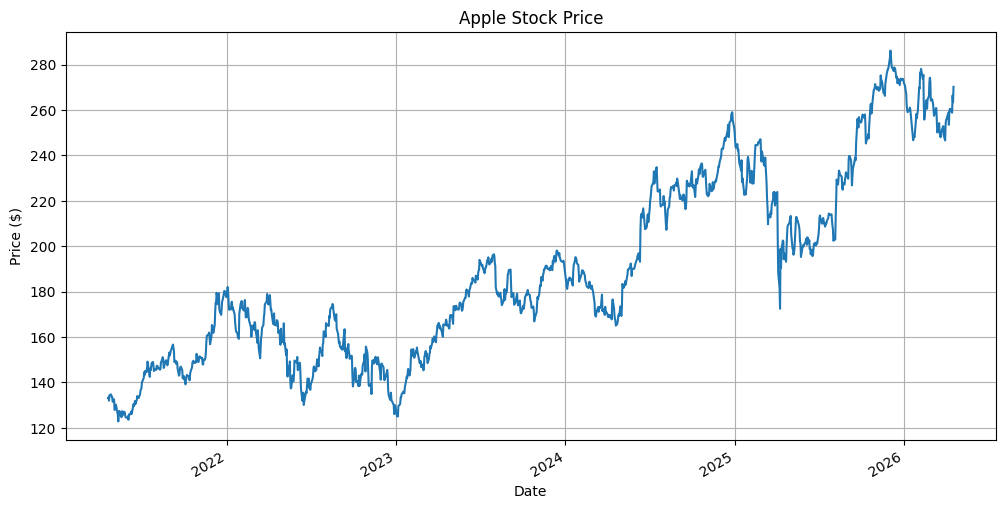

In [41]:
plt.figure(figsize=(12, 6))
Stock_prices['Close/Last'].plot()
plt.title('Apple Stock Price')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.grid(True)
plt.show()

Train set length: 1004
Test set length: 251


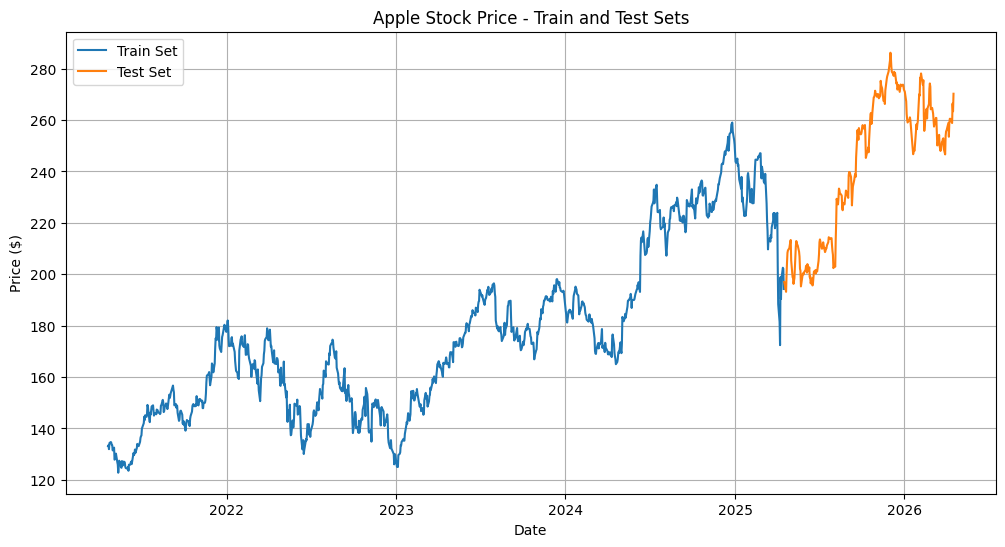

In [81]:
#train test split
test_ratio = 0.2
Test_set = Stock_prices.iloc[:int(len(Stock_prices) * test_ratio)]
Train_set = Stock_prices.iloc[int(len(Stock_prices) * test_ratio):]
print(f"Train set length: {len(Train_set)}")
print(f"Test set length: {len(Test_set)}")

#plotting train and test sets
plt.figure(figsize=(12, 6))
plt.plot(Train_set.index, Train_set['Close/Last'], label='Train Set')
plt.plot(Test_set.index, Test_set['Close/Last'], label='Test Set')
plt.title('Apple Stock Price - Train and Test Sets')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True)

Train and test set visualization. We can easily see a presence of micro trends and regimes changes in our data. That is the reason why we will proceed with returns transformation.

## Returns of Apple stock prices

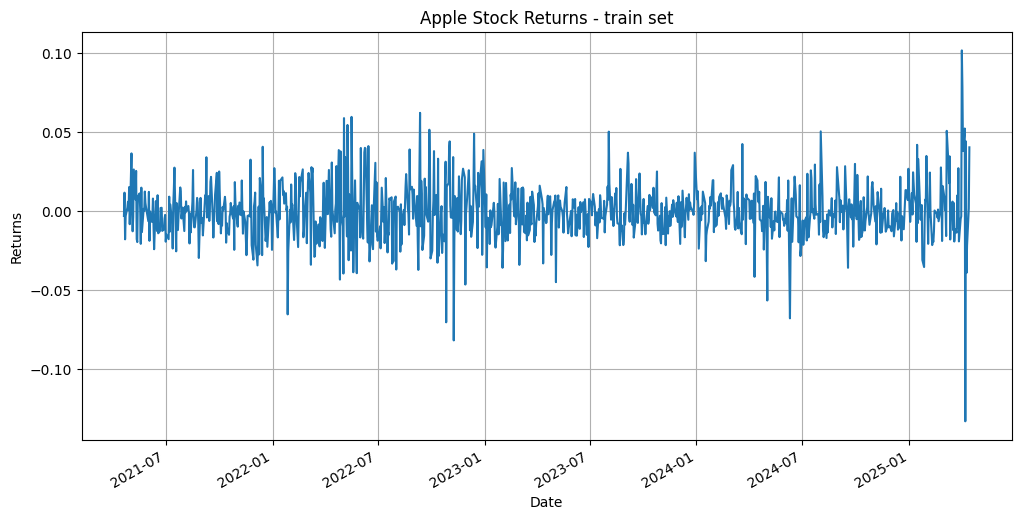

In [43]:
Train_returns = Train_set['Close/Last'].pct_change().dropna()
plt.figure(figsize=(12, 6))
Train_returns.plot()
plt.title('Apple Stock Returns - train set')
plt.xlabel('Date')
plt.ylabel('Returns')
plt.grid(True)
plt.show()

In [44]:
#ad fuller test
result = adfuller(Train_returns)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

ADF Statistic: -31.386028
p-value: 0.000000


Both ad fuller test and plot showed us that returns are stationary. Therefore we will further consider d parameter equals to 1 in **ARIMA(p,d,q)** model.

## Fitting **ARIMA** model

In [70]:
#ARIMA model
best_aic = np.inf
for p in range(0,5):
    for q in range(0,5):
        try:
            model = arima.model.ARIMA(Train_set['Close/Last'], order=(p, 1, q))
            model_fit = model.fit()
            if model_fit.aic < best_aic:
                best_aic = model_fit.aic
                best_order = (p, 1, q)
        except:
            continue
print(f"Best ARIMA order: {best_order} with AIC: {best_aic}")
model = arima.model.ARIMA(Train_set['Close/Last'], order=best_order)
model_fit = model.fit()
print(model_fit.summary())

c:\Users\Komputer\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Komputer\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Komputer\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Komputer\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but 

Best ARIMA order: (4, 1, 1) with AIC: 5124.691974209612
                               SARIMAX Results                                
Dep. Variable:             Close/Last   No. Observations:                 1004
Model:                 ARIMA(4, 1, 1)   Log Likelihood               -2556.346
Date:                Mon, 20 Apr 2026   AIC                           5124.692
Time:                        16:44:15   BIC                           5154.156
Sample:                             0   HQIC                          5135.889
                               - 1004                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9126      0.033    -27.920      0.000      -0.977      -0.848
ar.L2          0.0297      0.033      0.894      0.371      -0.035       0.

Using AIC criterion we found that the most suitable model for our data is **ARIMA(4,1,1)**. The value of AIC in this case is around 5125. The exact parameters of the considered model are shown in the table above.

## Autocorrelation and partial autocorrelation in training dataset

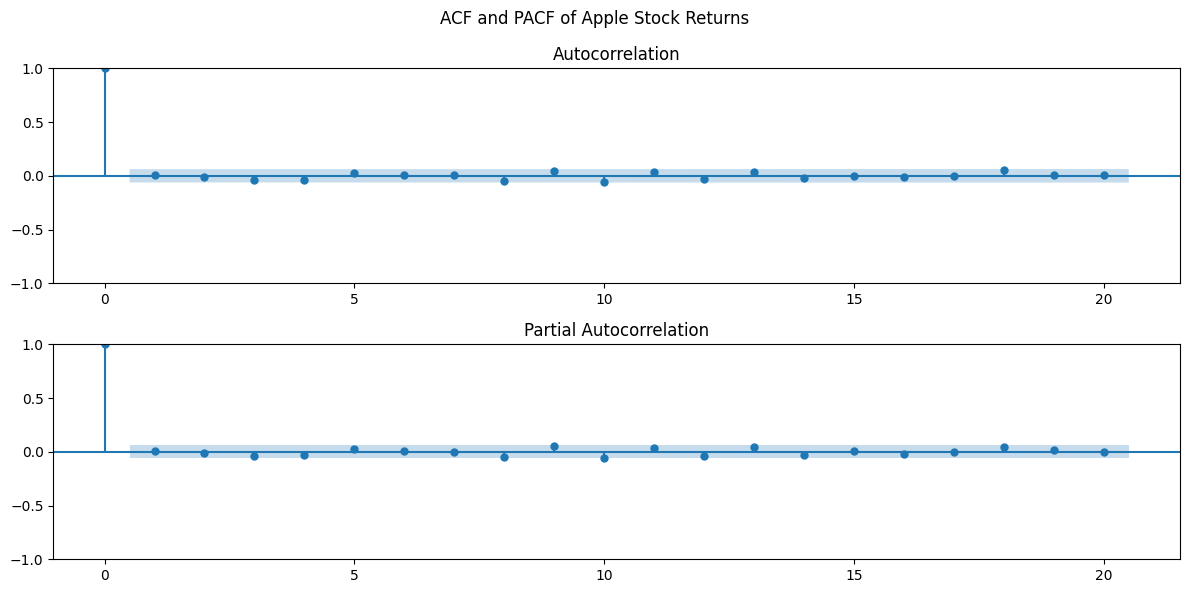

In [75]:
#pacf and acf plots
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plt.figure(figsize=(12, 6))
plt.suptitle('ACF and PACF of Apple Stock Returns')
plt.subplot(2, 1, 1)
plot_acf(Train_returns, ax=plt.gca(), lags=20)
plt.subplot(2, 1, 2)
plot_pacf(Train_returns, ax=plt.gca(), lags=20)
plt.tight_layout()
plt.show()

Autocorrelation and partial autocorrelation plots don't suggest to choose model fitted earlier. However we cannot consider model **ARIMA(0,1,0)** because it would mean that our returns are just a noise. Now let's analyze the residuals of our model.

## Residuals analysis

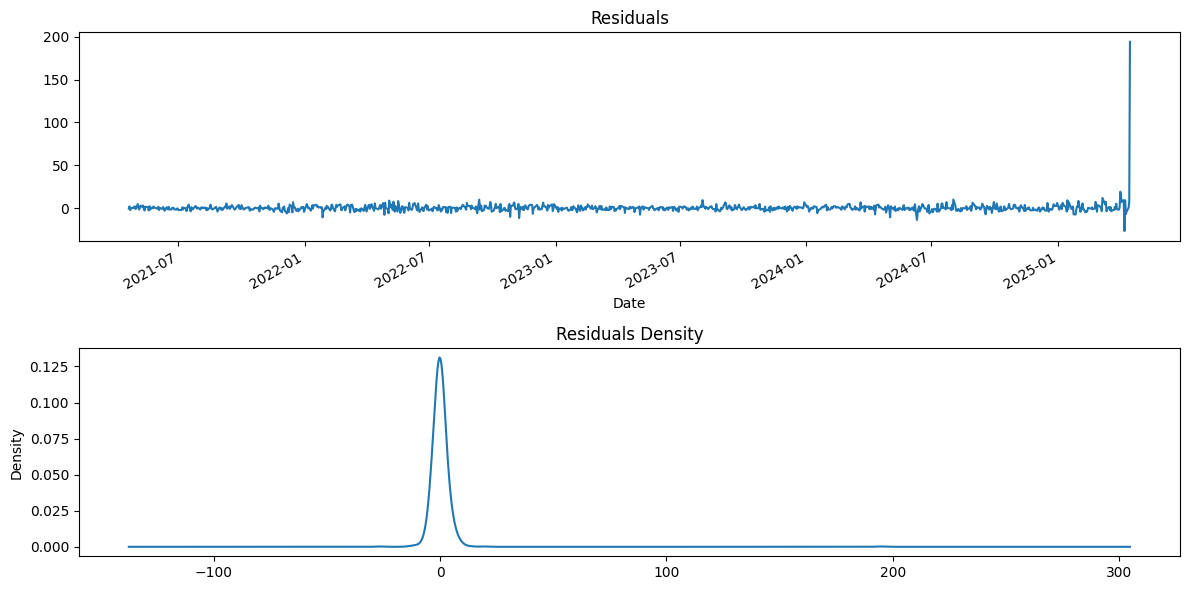

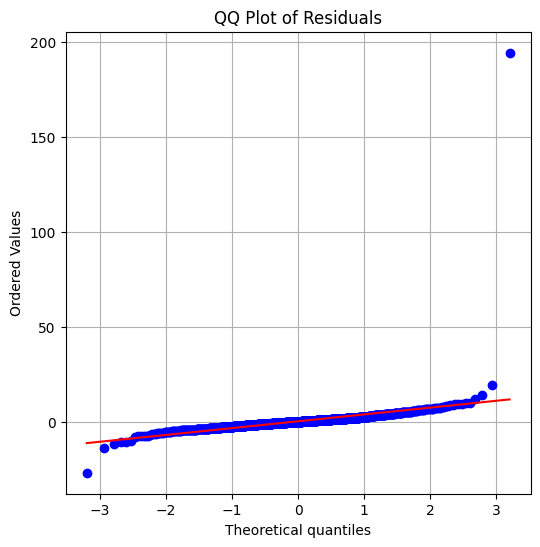

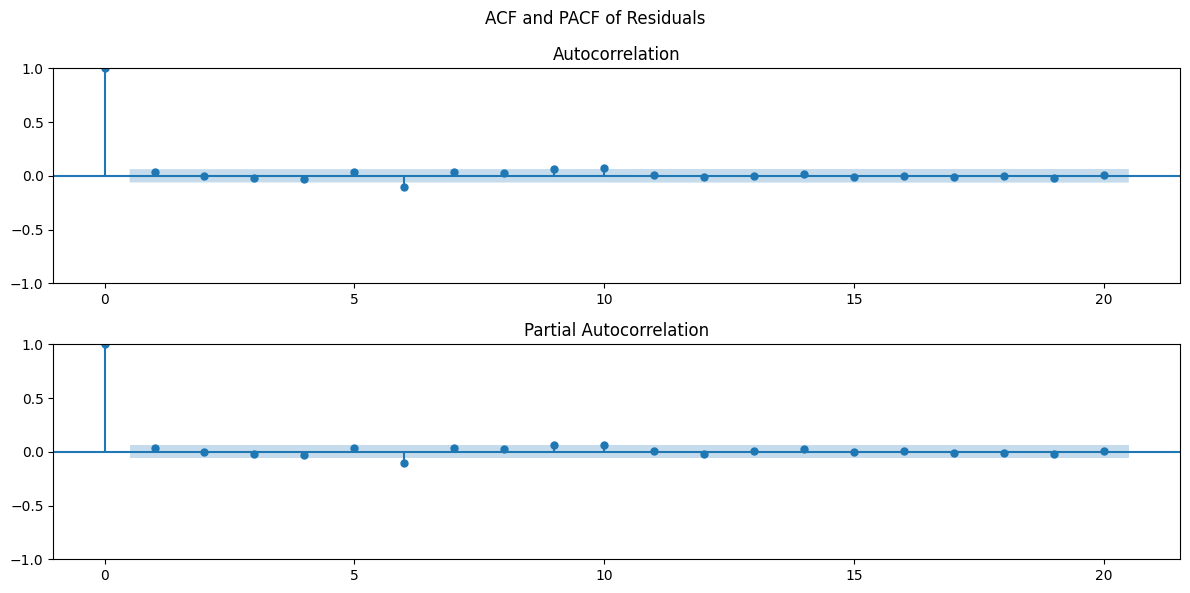

In [104]:
#residuals analysis
residuals = model_fit.resid
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
residuals.plot(title='Residuals')
plt.subplot(2, 1, 2)
residuals.plot(kind='kde', title='Residuals Density')
plt.tight_layout()
plt.show()

#qq plot of residuals
plt.figure(figsize=(6, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('QQ Plot of Residuals')
plt.grid(True)
plt.show()

#acf and pacf of residuals
plt.figure(figsize=(12, 6))
plt.suptitle('ACF and PACF of Residuals')
plt.subplot(2, 1, 1)
plot_acf(residuals, ax=plt.gca(), lags=20)
plt.subplot(2, 1, 2)
plot_pacf(residuals, ax=plt.gca(), lags=20)
plt.tight_layout()
plt.show()

In [106]:
#test for normality of residuals
statistic, p_value = stats.shapiro(residuals)
print(f'Shapiro-Wilk Test Statistic: {statistic}')
print(f'Shapiro-Wilk Test p-value: {p_value}')

Shapiro-Wilk Test Statistic: 0.2808141713224295
Shapiro-Wilk Test p-value: 3.245290993630673e-52


Residuals of our model seems to be uncorrelated, while their distribution is likely to have heavier tails than normal distribution (the hypothesis of our data to be normal is rejected by Shapiro-Wilk test at $\alpha = 0.05$). What is more there is one obvious outlier in our data, which makes distribution fitting rather a hard task. Now we will go throught validation of our model using the test dataset.

## Model validation

c:\Users\Komputer\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Komputer\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\Komputer\AppData\Local\Temp\ipykernel_4084\3070018279.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot(Test_set.index, predictions - Train_set['Close/Last'][-1] + Train_set['Close/Last'][0], label='Predictions')


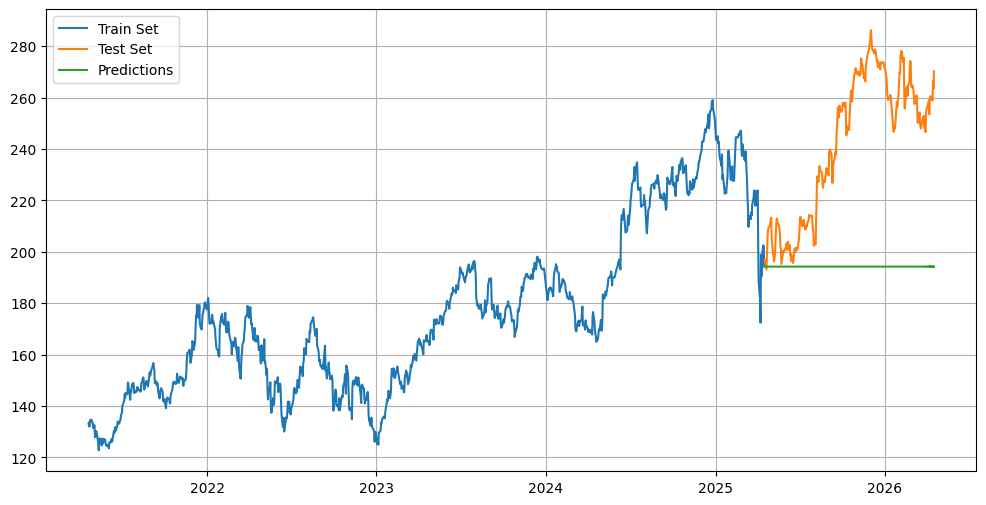

RMSE: 55.21195136007179
Mean of Test Set: 242.14414342629482


C:\Users\Komputer\AppData\Local\Temp\ipykernel_4084\3070018279.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  rmse = np.sqrt(np.mean((predictions.values - Test_set['Close/Last'] - Train_set['Close/Last'][-1] + Train_set['Close/Last'][0]).dropna()**2))


In [139]:
#model validation
predictions = model_fit.forecast(steps=len(Test_set))
plt.figure(figsize=(12, 6))
plt.plot(Train_set.index, Train_set['Close/Last'], label='Train Set')
plt.plot(Test_set.index, Test_set['Close/Last'], label='Test Set')
plt.plot(Test_set.index, predictions - Train_set['Close/Last'][-1] + Train_set['Close/Last'][0], label='Predictions')
plt.legend()
plt.grid(True)
plt.show()

#RSME calculation
rmse = np.sqrt(np.mean((predictions.values - Test_set['Close/Last'] - Train_set['Close/Last'][-1] + Train_set['Close/Last'][0]).dropna()**2))
print(f'RMSE: {rmse}')
print(f'Mean of Test Set: {Test_set["Close/Last"].mean()}')



We can see above that simple forcast based on expected value of **ARIMA** model is not efficient in long term. The value of RSME metric is around 55, while the average value of our data is about 242. Therefore the relative error is about 23% and makes this model unuseable.

c:\Users\Komputer\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Komputer\AppData\Local\Temp\ipykernel_4084\3375859693.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot(Test_set.index, model_fit.get_forecast(steps=len(Test_set)).conf_int(alpha=0.05).iloc[::-1, 0] - Train_set['Close/Last'][-1] + Train_set['Close/Last'][0], label='Lower Bound')
c:\Users\Komputer\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  r

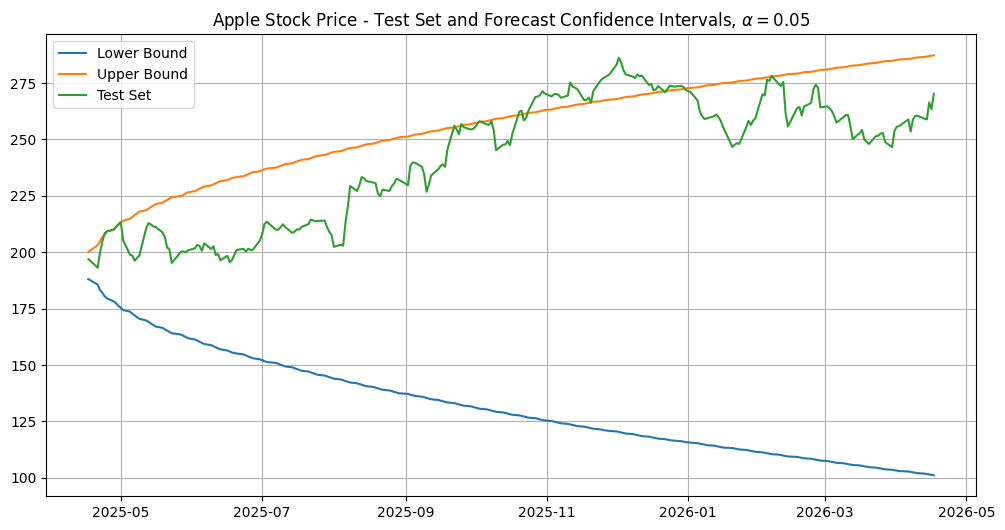

Coverage of 95% confidence intervals: 78.09%


c:\Users\Komputer\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Komputer\AppData\Local\Temp\ipykernel_4084\3375859693.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lower_bound = model_fit.get_forecast(steps=len(Test_set)).conf_int(alpha=0.05).iloc[::-1, 0] - Train_set['Close/Last'][-1] + Train_set['Close/Last'][0]
c:\Users\Komputer\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\U

In [144]:
#forecast quant lines
plt.figure(figsize=(12, 6))
plt.plot(Test_set.index, model_fit.get_forecast(steps=len(Test_set)).conf_int(alpha=0.05).iloc[::-1, 0] - Train_set['Close/Last'][-1] + Train_set['Close/Last'][0], label='Lower Bound')
plt.plot(Test_set.index, model_fit.get_forecast(steps=len(Test_set)).conf_int(alpha=0.05).iloc[::-1, 1] - Train_set['Close/Last'][-1] + Train_set['Close/Last'][0], label='Upper Bound')
plt.plot(Test_set.index, Test_set['Close/Last'], label='Test Set')
plt.title(r'Apple Stock Price - Test Set and Forecast Confidence Intervals, $\alpha=0.05$')
plt.legend()
plt.grid(True)
plt.show()

#coverage of confidence intervals
lower_bound = model_fit.get_forecast(steps=len(Test_set)).conf_int(alpha=0.05).iloc[::-1, 0] - Train_set['Close/Last'][-1] + Train_set['Close/Last'][0]
upper_bound = model_fit.get_forecast(steps=len(Test_set)).conf_int(alpha=0.05).iloc[::-1, 1] - Train_set['Close/Last'][-1] + Train_set['Close/Last'][0]
coverage = np.mean((Test_set['Close/Last'] >= lower_bound.values) & (Test_set['Close/Last'] <= upper_bound.values))
print(f'Coverage of 95% confidence intervals: {coverage:.2%}')


What is more the coverage of quantiles lines obtained via **ARIMA** model differs significantly from theoretical values. For 95% confidence interval, only 78.09% of actual observations is included. It suggest that for this particular dataset we should take diffrent modeling approach.

## **ARIMA** for full dataset

As a finnal step we will train **ARIMA(4,1,1)** once again, this time utilizing whole dataset as training data. Then we will consider 30-days long forecast consisting of confidence intervals and expected value. 

In [145]:
#ARIMA for whole dataset
model_full = arima.model.ARIMA(Stock_prices['Close/Last'], order=best_order)
model_full_fit = model_full.fit()
print(model_full_fit.summary())

c:\Users\Komputer\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Komputer\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Komputer\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Komputer\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but 

                               SARIMAX Results                                
Dep. Variable:             Close/Last   No. Observations:                 1255
Model:                 ARIMA(4, 1, 1)   Log Likelihood               -3235.226
Date:                Mon, 20 Apr 2026   AIC                           6482.452
Time:                        18:44:12   BIC                           6513.257
Sample:                             0   HQIC                          6494.031
                               - 1255                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8590      0.201      4.268      0.000       0.464       1.253
ar.L2         -0.0273      0.028     -0.979      0.327      -0.082       0.027
ar.L3         -0.0474      0.026     -1.835      0.0

Interestingly we can observe that not only the values of model coefficients changed compared to the old model, but also their sign changed in some cases. Now let us consider the 30-days forecast mentioned before.

c:\Users\Komputer\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Komputer\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Komputer\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


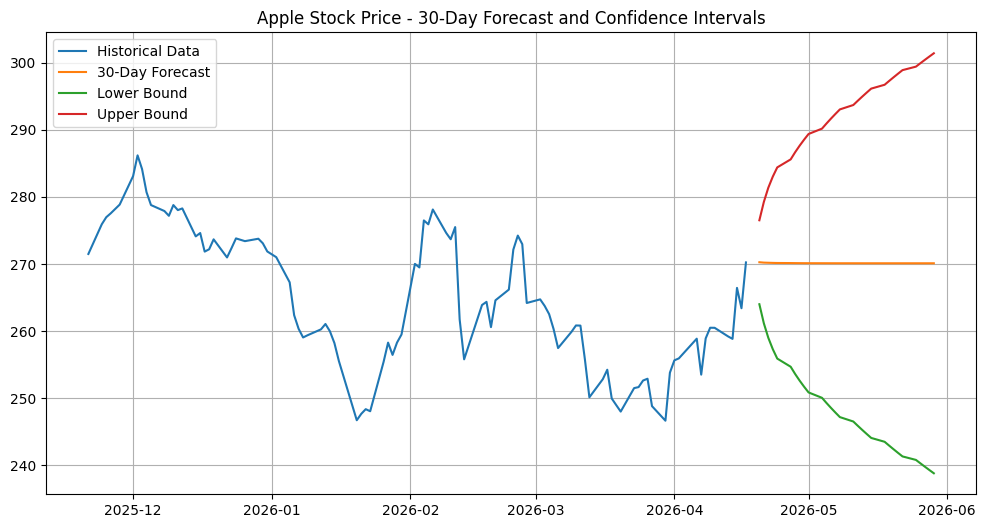

In [154]:
#30-day forecast and confidence intervals plot
forecast_30 = model_full_fit.forecast(steps=30)
plt.figure(figsize=(12, 6))
plt.plot(Stock_prices.index[:100], Stock_prices['Close/Last'][:100], label='Historical Data')
forecast_index = pd.date_range(start=Stock_prices.index[0] + pd.Timedelta(days=1), periods=30, freq='B')
plt.plot(forecast_index, forecast_30 - Stock_prices['Close/Last'].iloc[-1] + Stock_prices['Close/Last'].iloc[0], label='30-Day Forecast')      
plt.plot(forecast_index, model_full_fit.get_forecast(steps=31).conf_int(alpha=0.05).iloc[:-1, 0] - Stock_prices['Close/Last'].iloc[-1] + Stock_prices['Close/Last'].iloc[0], label='Lower Bound')
plt.plot(forecast_index, model_full_fit.get_forecast(steps=31).conf_int(alpha=0.05).iloc[:-1, 1] - Stock_prices['Close/Last'].iloc[-1] + Stock_prices['Close/Last'].iloc[0], label='Upper Bound')
plt.title('Apple Stock Price - 30-Day Forecast and Confidence Intervals')
plt.legend()
plt.grid(True)
plt.show()


Our work ends there because we do not have access to the future values of Apple stock prices (unfortunately). However based on previous analysis we should be suspicious about this forecast. The only rational observation to conclude is the fact that above graph looks like chineese dragon.

# Problem 4

## Data loading 

In this problem we will consider the prices of S&P500. The data is from 12.04.2010-21.04.2026 period. 

In [5]:
path = 'SP500_prices.csv'
SP500_prices = pd.read_csv(path, index_col=0, parse_dates=True)
SP500_prices.head()

,Open,High,Low,Close,Volume
Date,,,,,
2010-04-12,1194.94,1199.20,1194.71,1196.48,2.559494e+09
2010-04-13,1195.94,1199.04,1188.82,1197.30,3.001989e+09
2010-04-14,1198.69,1210.65,1198.69,1210.65,3.200022e+09
2010-04-15,1210.77,1213.92,1208.50,1211.67,3.330739e+09
2010-04-16,1210.17,1210.17,1186.77,1192.13,4.504706e+09


## Data visualization

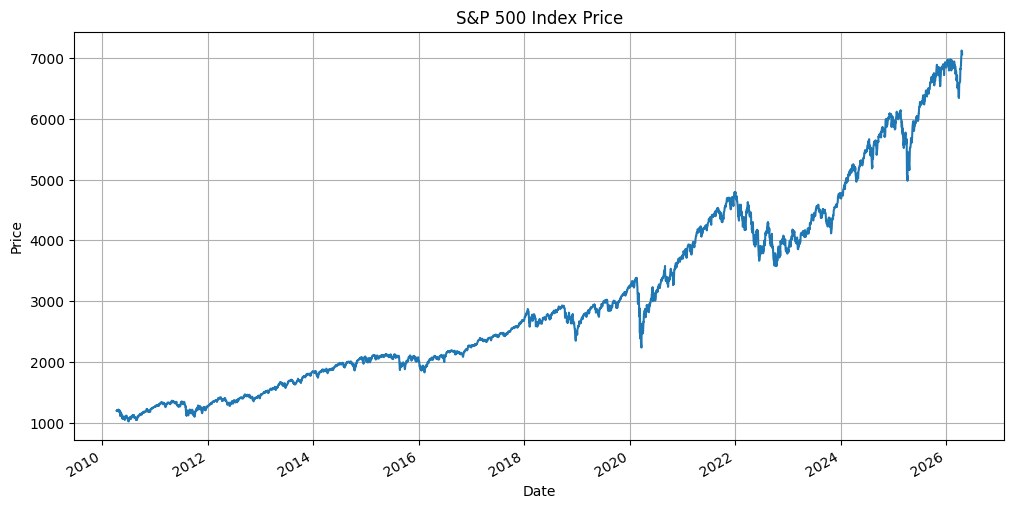

In [6]:
plt.figure(figsize=(12, 6))
SP500_prices['Close'].plot()
plt.title('S&P 500 Index Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.show()

## Log returns

Now we will introduce the transformation of the data, which is given by the formula
$$
R_t = \log(\frac{P_t}{P_{t-1}}),
$$
where $P_t$ is the price at day $t$ and $R_t$ is log return at day $t$.

Train set length: 4011
Test set length: 20
ADF Statistic: -13.692360
p-value: 0.000000


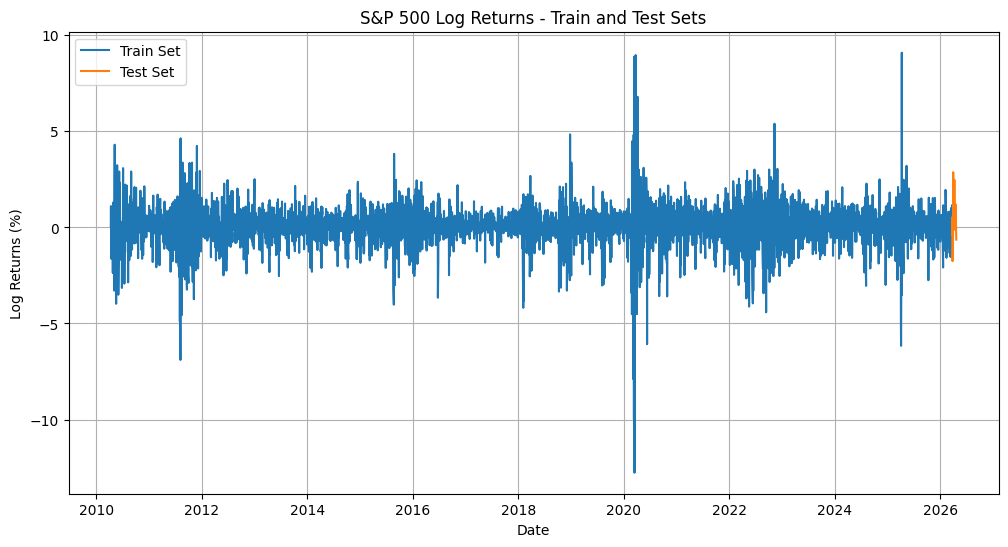

In [43]:
log_returns = np.log(SP500_prices['Close'] / SP500_prices['Close'].shift(1)).dropna()

test_set_elements = 20
Test_set = 100*log_returns.iloc[-test_set_elements:]
Train_set = 100*log_returns.iloc[:-test_set_elements]
print(f"Train set length: {len(Train_set)}")
print(f"Test set length: {len(Test_set)}")

adfuller_result = adfuller(Train_set)
print('ADF Statistic: %f' % adfuller_result[0])
print('p-value: %f' % adfuller_result[1])

plt.figure(figsize=(12, 6))
plt.plot(Train_set.index, Train_set, label='Train Set')
plt.plot(Test_set.index, Test_set, label='Test Set')
plt.title('S&P 500 Log Returns - Train and Test Sets')
plt.xlabel('Date')
plt.ylabel('Log Returns (%)')
plt.legend()
plt.grid(True)
plt.show()

The graph above shows us the change of log returns in time. We also performed the ad Fuller test, which showed us that after the transformation our data is the stationary time series ($\alpha=0.05$). We also splited the dataset into training and test set, which are visualized with diffrent colors.

## ACF and PACF of training dataset

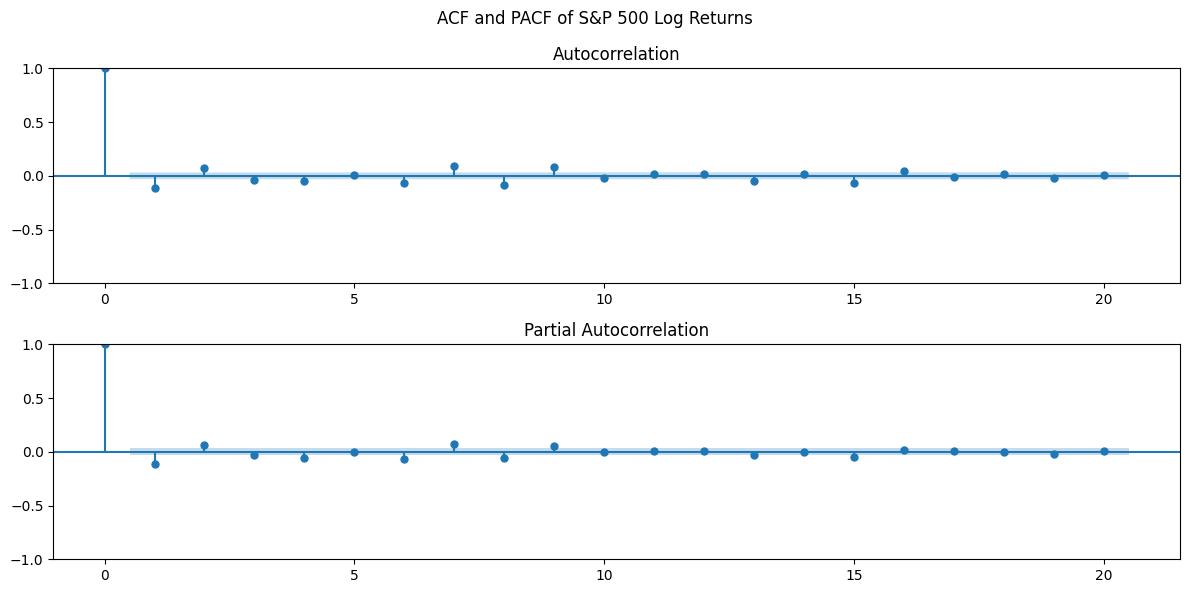

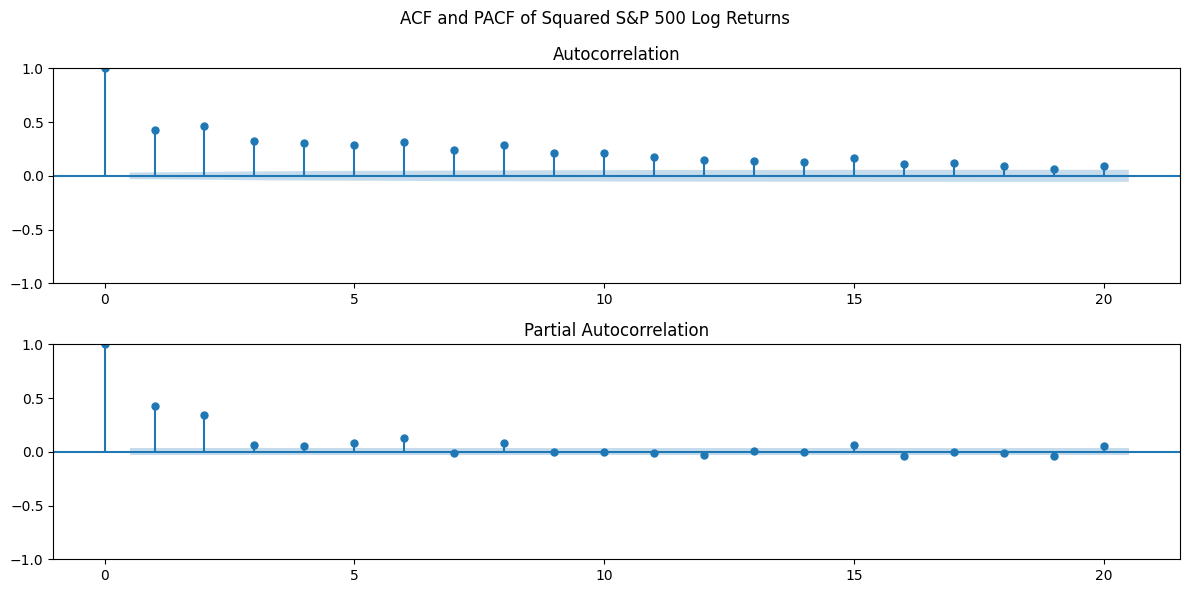

In [27]:
#ACF and PACF plots for data and squared data
plt.figure(figsize=(12, 6))
plt.suptitle('ACF and PACF of S&P 500 Log Returns')
plt.subplot(2, 1, 1)
plot_acf(Train_set, ax=plt.gca(), lags=20)
plt.subplot(2, 1, 2)
plot_pacf(Train_set, ax=plt.gca(), lags=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.suptitle('ACF and PACF of Squared S&P 500 Log Returns')
plt.subplot(2, 1, 1)
plot_acf(Train_set**2, ax=plt.gca(), lags=20)
plt.subplot(2, 1, 2)
plot_pacf(Train_set**2, ax=plt.gca(), lags=20)
plt.tight_layout()
plt.show()


We can observe that there is no autocorrelation and partial autocorellation in our training set. However there are visually present autocorrelation and partial autocorellation in the squares of our training set. This implies that we are dealing with **GARCH** effect. In the next step we will fit **GARCH(1,1)** to our data - as a exercise says us to do. However the PACF plot suggest that we should also consider **GARCH(2,1)**.

## Fitting **GARCH(1,1)**

Just to remind, the $X_t$ is the GARCH(1,1) process if 
$$
X_t = \sigma_t Z_t
$$ \
$$
\sigma_t^2 = \omega + \alpha X_{t-1}^2 + \beta \sigma_{t-1}^2 
$$ \
where $Z_t$ is a white noise process, $\omega > 0$, $\alpha \geq 0$, $\beta \geq 0$. 

In [28]:
#fitting GARCH(1,1) model
model_garch = arch_model(Train_set, vol='Garch', p=1, q=1)
model_garch_fit = model_garch.fit(disp='off')
print(model_garch_fit.summary())


                     Constant Mean - GARCH Model Results                      
Dep. Variable:                  Close   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -5173.24
Distribution:                  Normal   AIC:                           10354.5
Method:            Maximum Likelihood   BIC:                           10379.7
                                        No. Observations:                 4011
Date:                Wed, Apr 22 2026   Df Residuals:                     4010
Time:                        15:30:26   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0752  1.202e-02      6.256  3.952e-10 [5.

We see that coofiecents of fitted model are pretty certain. Furthermore this **GARCH(1,1)** is stationary because \
 $\alpha + \beta < 1$. Now we illustrate the conditional volatility obtain via our model for training dataset.

## Conditional volatility

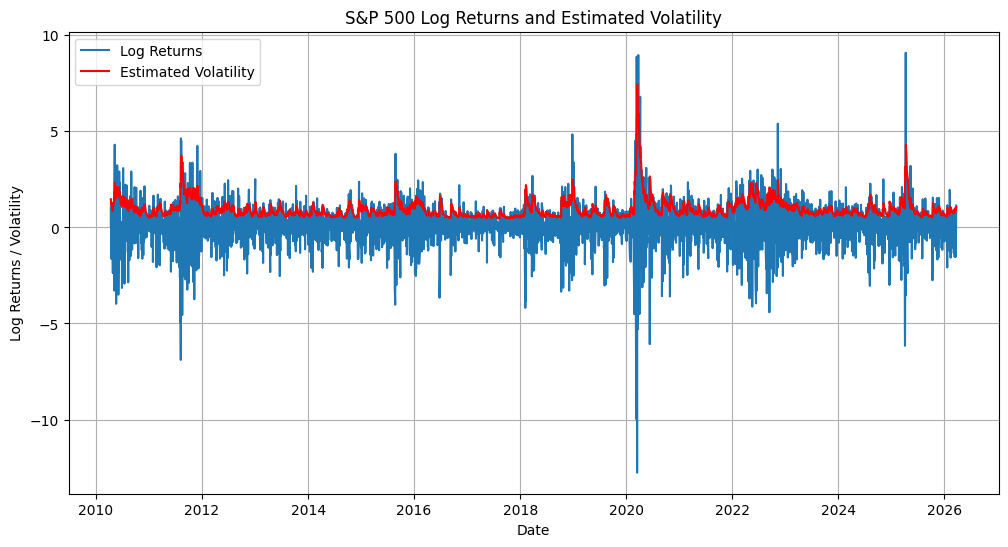

In [29]:
#ilustrate in sample volatility
plt.figure(figsize=(12, 6))
plt.plot(Train_set.index, Train_set, label='Log Returns')
plt.plot(Train_set.index, model_garch_fit.conditional_volatility, label='Estimated Volatility', color='red')
plt.title('S&P 500 Log Returns and Estimated Volatility')
plt.xlabel('Date')
plt.ylabel('Log Returns / Volatility')
plt.legend()
plt.grid(True)  
plt.show()

We see that calculated volatility suits well to actual data. Now we analyse the standardized residuals of obtained model.

## Standardized residuals

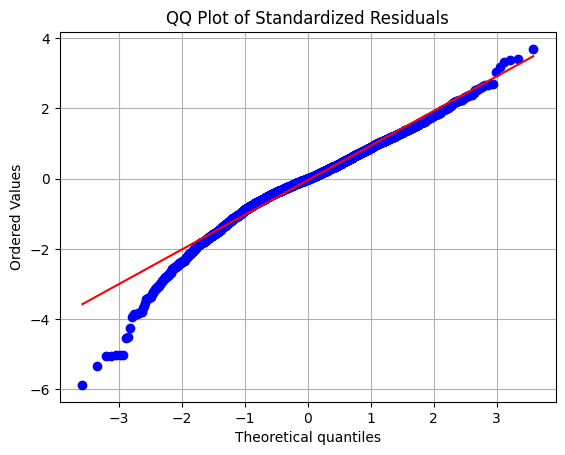

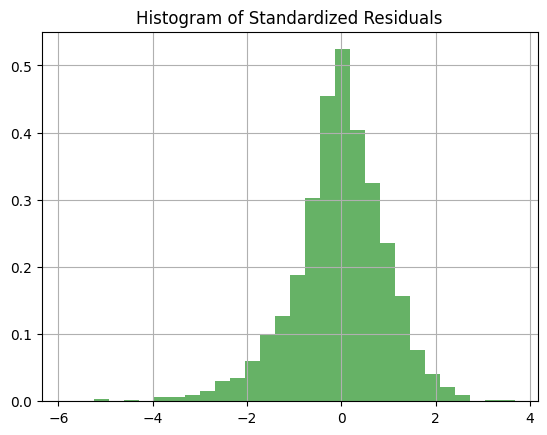

In [42]:
#analyze standarized residuals of GARCH model
standardized_residuals = model_garch_fit.resid / model_garch_fit.conditional_volatility
stats.probplot(standardized_residuals, dist="norm", plot=plt)
plt.title('QQ Plot of Standardized Residuals')
plt.grid(True)
plt.show()

plt.hist(standardized_residuals, bins=30, density=True, alpha=0.6, color='g')
plt.title('Histogram of Standardized Residuals')     
plt.grid(True)
plt.show()   



Both, q-q plot and density histogram shows us that the distribution of $Z_t$ in our model is left hand skewed. What is more the q-q plot gives us strong visual evidence that the left tail is heavier comparing to normal case. Those facts suggest that the GJR-GARCH would be better choise to our data. This model is capable of capturing asymmetric volatility in financial time series, specifically the "leverage effect"— where negative shocks increase volatility more than positive shocks. In summary our $Z_t$ is not normal.

## 20 days forecast - model validation

Now we perform the 20 days long volatility forecast. 

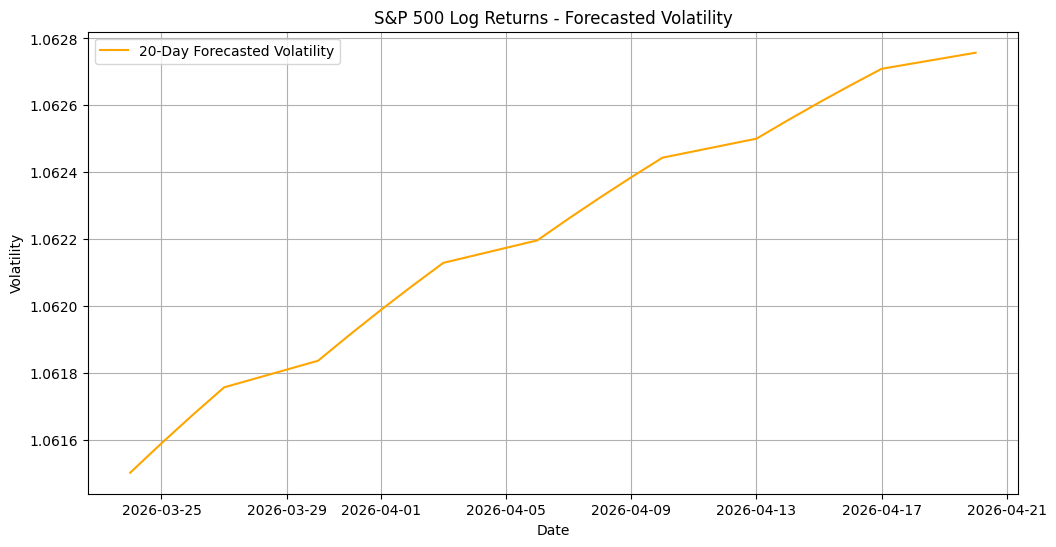

In [ ]:
# 20 days forecast of volatility vs test set
garch_forecast = model_garch_fit.forecast(horizon=20)
plt.figure(figsize=(12, 6))
forecast_index = pd.date_range(start=Train_set.index[-1] + pd.Timedelta(days=1), periods=20, freq='B')
plt.plot(forecast_index, np.sqrt(garch_forecast.variance.values[-1]), label='20-Day Forecasted Volatility', color='orange')
plt.title('S&P 500 Log Returns - Forecasted Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend()
plt.grid(True)
plt.show()

We see that our model predicted the slowly increasing volatility for several days. Now we compare this resoult with the absolute value of training dataset.

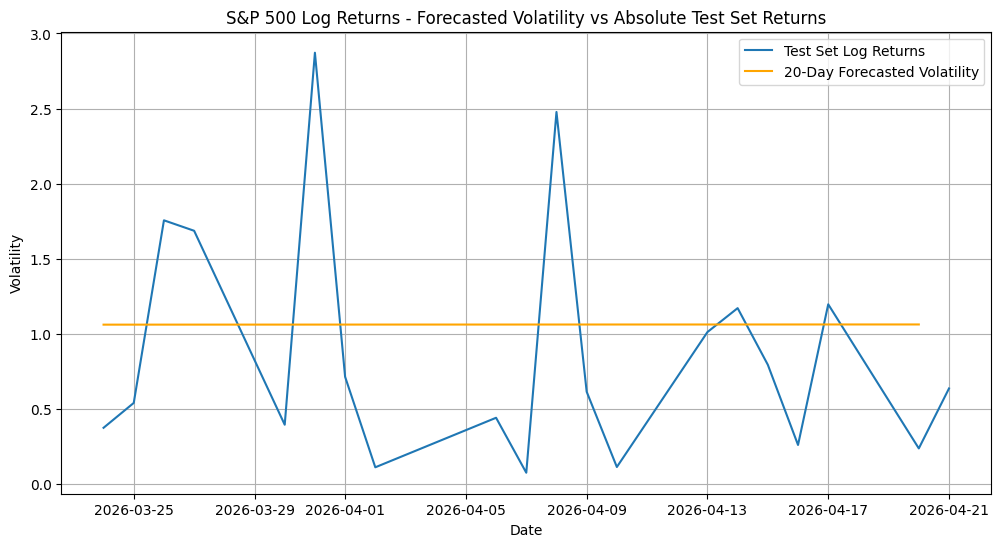

Average Forecasted Volatility: 1.0622
Average Absolute Test Set Returns: 0.8742


In [46]:
# 20 days forecast of volatility vs test set
garch_forecast = model_garch_fit.forecast(horizon=20)
plt.figure(figsize=(12, 6))
plt.plot(Test_set.index, np.abs(Test_set), label='Test Set Log Returns')
forecast_index = pd.date_range(start=Train_set.index[-1] + pd.Timedelta(days=1), periods=20, freq='B')
plt.plot(forecast_index, np.sqrt(garch_forecast.variance.values[-1]), label='20-Day Forecasted Volatility', color='orange')
plt.title('S&P 500 Log Returns - Forecasted Volatility vs Absolute Test Set Returns')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend()
plt.grid(True)
plt.show()

#avg comparison of forecasted volatility and absolute test set returns
avg_forecasted_volatility = np.mean(np.sqrt(garch_forecast.variance.values[-1]))
avg_absolute_test_returns = np.mean(np.abs(Test_set))
print(f'Average Forecasted Volatility: {avg_forecasted_volatility:.4f}')
print(f'Average Absolute Test Set Returns: {avg_absolute_test_returns:.4f}')

The predicted volatility is rather constant comparing to the absolute value of training dataset. However the mean values of both are preety close to each other. Now we compare predicted volatility with the Garman-Kloas volatility estimator for training dataset.

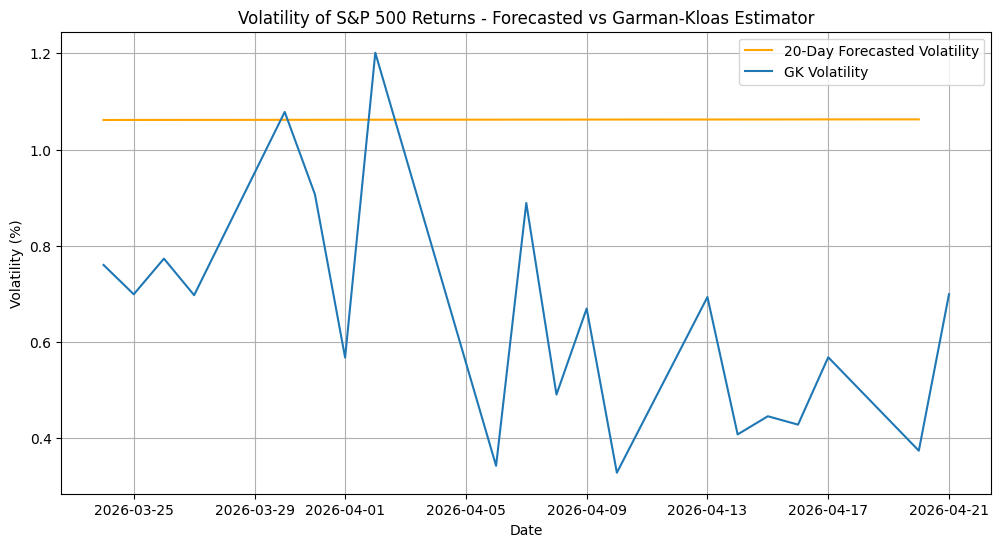

Average Forecasted Volatility: 1.0622
Average GK Volatility: 0.6512


In [48]:
#actual volatility calculated using Garman-Kloas estimator
High = SP500_prices['High'].iloc[-test_set_elements:]
Low = SP500_prices['Low'].iloc[-test_set_elements:]
Open = SP500_prices['Open'].iloc[-test_set_elements:]
Close = SP500_prices['Close'].iloc[-test_set_elements:]

GK_volatility = 100 *np.sqrt(0.5 * (np.log(High/Low) )**2 - (2 * np.log(2) - 1) * (np.log(Close/Open))**2)

plt.figure(figsize=(12, 6))
plt.plot(forecast_index, np.sqrt(garch_forecast.variance.values[-1]), label='20-Day Forecasted Volatility', color='orange')
plt.plot(Test_set.index, GK_volatility, label='GK Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility (%)')
plt.title('Volatility of S&P 500 Returns - Forecasted vs Garman-Kloas Estimator')
plt.legend()
plt.grid(True)
plt.show()

#avg comparison of forecasted volatility and GK volatility
avg_GK_volatility = np.mean(GK_volatility)
print(f'Average Forecasted Volatility: {avg_forecasted_volatility:.4f}')
print(f'Average GK Volatility: {avg_GK_volatility:.4f}')

Once again we can observe that the predicted volatility is rather constant comparing to the Garman-Kloas volatility estimator for training dataset. However in this case the mean value of our prediction is higher than estimated value for almost every day.

As a conclusion we state that fitted **GARCH(1,1)** is rather to simple to effectively model our data.